#### 1. Setup

In [45]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [ ]:
os.getenv("GROQ_API_KEY")

In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="openai/gpt-oss-120b")

In [4]:
res = llm.invoke("Hello !")
res.content

'Hello! 👋 How can I help you today?'

#### 2. State - Global State to pass the data b/w all the nodes

In [1]:
from pydantic import BaseModel

class UserState(BaseModel):
    name: str = ""
    email: str = ""
    age: int = 0
    
state = UserState(name="Prateek")

In [2]:
state

UserState(name='Prateek', email='', age=0)

##### 2.1 Building the Graph Using Langgraph

In [23]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

class MyState(BaseModel):
    messages: str = ""

def greet(state: MyState):
    "I am a greeting node ..."
    print("[NODE] Responce - ", state.messages)
    # state.messages = "Good Morning!" # Set as default for each state
    return state

graph = StateGraph(MyState)

graph.add_node("welcome", greet)  # Method name, Method

graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

final_graph = graph.compile()

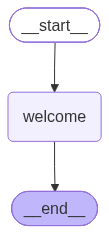

In [24]:
final_graph

In [25]:
res = final_graph.invoke({"messages": "HEllo, How are you tell everyone ?"})

[NODE] Responce -  HEllo, How are you tell everyone ?


In [26]:
res

{'messages': 'HEllo, How are you tell everyone ?'}

##### 2.2 Multi Node Graph

In [ ]:
from random import randint

class ReviewState(BaseModel):
    text: str = ""
    score: int = 0
    comments: str = ""


def score(state:ReviewState) -> ReviewState :
    state.score = randint(1, 10)
    return state


# def commenter(state:ReviewState) - This only tells Python: "state is expected to be a ReviewState."

def commenter(state:ReviewState) -> ReviewState :
# -> ReviewState means "this function returns a ReviewState"
    if state.score > 5:
        state.comments = "Well Done"
    else:
        state.comments = "Need Improvement"
    return state


graph = StateGraph(ReviewState)
graph.add_node("score", score)
graph.add_node("commenter", commenter)

graph.add_edge(START, "score")
graph.add_edge("score", "commenter")
graph.add_edge("commenter", END)

final_graph = graph.compile()

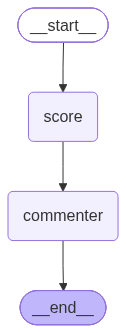

In [32]:
final_graph

In [33]:
res = final_graph.invoke({})

In [34]:
res

{'text': '', 'score': 3, 'comments': 'Need Improvement'}

##### 3. `add_messages` reducer - for chat history

In [58]:
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage
from typing import Annotated
from langchain_groq import ChatGroq


llm = ChatGroq(model="openai/gpt-oss-120b")


def custom_reducer(existing: list, new: list):
    all_msg = existing + new
    return all_msg[-1:]

def isPositive(existing:int, new:int):
    if new < 0:
        return 0
    return new


class ChatState(BaseModel):
    messages: Annotated[list, add_messages] = []
    count : Annotated[int, isPositive] = 0

def chat_bot(state:ChatState):
    state.messages = [llm.invoke(state.messages)]
    state.count = -10
    return state


graph = StateGraph(ChatState)

graph.add_node("chat_bot", chat_bot)
graph.add_edge(START, "chat_bot")
graph.add_edge("chat_bot", END)

final_graph = graph.compile()

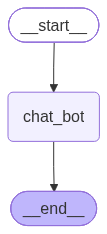

In [53]:
final_graph

In [59]:
res = final_graph.invoke({"messages": [ HumanMessage(content="Hello, Hows you ?") ]})

In [60]:
res

{'messages': [HumanMessage(content='Hello, Hows you ?', additional_kwargs={}, response_metadata={}, id='1ffacfa1-6584-4a11-8dff-41da53334d8c'),
  AIMessage(content="Hello! I'm doing well, thank you. How are you today?", additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hello, Hows you ?" Probably a typo. We should respond politely, ask how they are, maybe correct grammar. No special instructions. So just respond.'}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 77, 'total_tokens': 145, 'completion_time': 0.146622955, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.012925058, 'prompt_tokens_details': None, 'queue_time': 0.336470627, 'total_time': 0.159548013}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_47082602e2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a11b17-d8a7-7d63-9378-55edfbc37a4f-0', tool_calls=[

#### 4. Routing - Langgraph Core Component

In [62]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Literal

class TicketState(BaseModel):
    issue:str = ""
    category: str = ""
    response: str = ""

def classify(state: TicketState) -> TicketState:
    issue = state.issue.lower()
    if "payment" in issue or "ammount" in issue:
        state.category = "billing"
    elif "refund" in issue or "cancle" in issue:
        state.category = "refund"
    else :
        state.category = "status"
    return state

def handle_billing(state: TicketState) -> TicketState:
    print("Billing related issue.")
    state.response = f"Issue resolved for {state.issue}"
    return state 

def handle_refund(state: TicketState) -> TicketState:
    print("Refund related issue.")
    state.response = f"Issue resolved for {state.issue}"
    return state 

def handle_status(state: TicketState) -> TicketState:
    print("Status related issue.")
    state.response = f"Issue resolved for {state.issue}"
    return state


### This is not my node 
def router_logic(state:TicketState) -> Literal["billing", "refund", "status"]:
    return state.category

graph = StateGraph(TicketState)
graph.add_node("classify", classify)
graph.add_node("handle_billing", handle_billing)
graph.add_node("handle_refund", handle_refund)
graph.add_node("handle_status", handle_status)

graph.add_edge(START, "classify")
graph.add_conditional_edges("classify", router_logic, 
                    {"billing": "handle_billing", 
                    "status": "handle_status", 
                    "refund": "handle_refund"} 
)
graph.add_edge("handle_billing", END)
graph.add_edge("handle_refund", END)
graph.add_edge("handle_status", END)

final_graph = graph.compile()

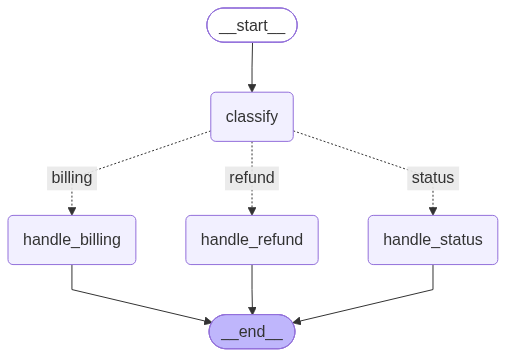

In [63]:
final_graph

In [66]:
res = final_graph.invoke({"issue": "I am waiting for my Feedback "})

Status related issue.


In [67]:
res

{'issue': 'I am waiting for my Feedback ',
 'category': 'status',
 'response': 'Issue resolved for I am waiting for my Feedback '}

#### 5. memory - checkpointer

In [73]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Annotated
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage


class ChatState(BaseModel):
    messages: Annotated[list, add_messages]
    
def chat_bot(state:ChatState):
    state.messages = [llm.invoke(state.messages)]
    return state

graph = StateGraph(ChatState)

graph.add_node("chat_bot", chat_bot)
graph.add_edge(START, "chat_bot")
graph.add_edge("chat_bot", END)



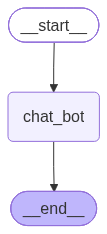

In [ ]:
# # Without memory Implementaion

# final_graph = graph.compile()
# final_graph

In [ ]:
# res = final_graph.invoke({"messages": [ HumanMessage(content="Who is his father ?") ]})
# ans = res["messages"][-1].content
# print(ans)

I’m not sure who you’re referring to. Could you let me know which person you mean?


In [74]:
memory = InMemorySaver()
final_graph = graph.compile(checkpointer=memory)

In [76]:
res = final_graph.invoke(
        {"messages": [ HumanMessage(content="Who is his father?")]},
        {"configurable": {"thread_id":"chat-1"}}
    )
ans = res["messages"][-1].content
print(ans)

Narendra Modi’s father was **Damodardas Mulchand Modi** (sometimes written as Damodardas Modi).  

* **Occupation:** He ran a small tea‑stall (chai‑walla) near the railway station in Vadnagar, Gujarat.  
* **Background:** The family belonged to the **Gujarat Modh‑Bania** community, a trading/merchant caste.  
* **Influence:** Growing up in a modest, low‑income household, Narendra Modi often recounts how his father’s hard‑working, disciplined approach and his early exposure to the tea‑stall business shaped his own work ethic and outlook on life.  

Damodardas Modi passed away in 1989, when Narendra Modi was in his late 30s and already active in local politics. His life story is frequently cited by Modi himself as an example of rising from humble beginnings to national leadership.


##### Using SQLite Memory

In [77]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

connection = sqlite3.connect("db.sqlite3", check_same_thread=False)
sql_memory = SqliteSaver(connection)
sql_memory.setup()

In [79]:
sqlite_graph = graph.compile(checkpointer=sql_memory)

In [81]:
res = sqlite_graph.invoke(
        {"messages": [ HumanMessage(content="Who is his age?")]},
        {"configurable": {"thread_id":"chat-1"}}
    )
ans = res["messages"][-1].content
print(ans)

Narendra Modi was born on **17 September 1950**.  

- As of today, **8 October 2026**, he is **76 years old** (he turned 76 just a few weeks ago).
